# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Mawarni Lubis
- **Email:** mawarnilubis4@gmail.com
- **ID Dicoding:** mawarni_lubis

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (kategori cuaca, suhu, dan kelembaban) terhadap jumlah total penyewaan sepeda harian selama periode 2011-2012?
- **Pertanyaan 2:** Bagaimana perbedaan kontribusi jumlah penyewaan antara pengguna Casual dan Registered berdasarkan hari dalam seminggu selama tahun 2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Mengatur tampilan visualisasi agar lebih konsisten
sns.set(style="whitegrid")
%matplotlib inline

## Penjelasan singkat fungsinya:

- numpy (np): Digunakan untuk operasi matematika dan manipulasi array jika diperlukan dalam perhitungan statistik.
- pandas (pd): Library utama yang akan Anda gunakan untuk memuat dataset (CSV), membersihkan data (cleaning), dan melakukan agregasi data.
- matplotlib.pyplot (plt): Library dasar untuk membuat visualisasi data seperti line chart atau bar chart.
- seaborn (sns): Library visualisasi tingkat lanjut berbasis Matplotlib yang membuat tampilan grafik Anda lebih menarik dan profesional (Penting untuk mengejar nilai Bintang 5 pada kriteria desain).
- datetime: Diperlukan untuk memproses kolom tanggal agar Anda bisa melakukan analisis berdasarkan tren waktu (seperti membedakan tahun 2011 dan 2012).

## Data Wrangling

### Gathering Data

In [2]:
# Memuat dataset day.csv
day_df = pd.read_csv("day.csv")

# Memuat dataset hour.csv
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama dari day_df
print("Data Harian (day_df):")
display(day_df.head())

# Menampilkan 5 baris pertama dari hour_df
print("\nData Per Jam (hour_df):")
display(hour_df.head())

Data Harian (day_df):


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Data Per Jam (hour_df):


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

- Dataset day_df terdiri dari 731 baris yang merepresentasikan data harian. Data ini cocok untuk menjawab Pertanyaan 1 terkait pengaruh cuaca harian.
- Dataset hour_df terdiri dari 17.379 baris yang merepresentasikan data per jam. Data ini akan digunakan untuk menjawab Pertanyaan 2 terkait pola penggunaan berdasarkan jam.
- Kedua dataset memiliki kolom-kolom kunci yang sama seperti dteday (tanggal), weathersit (kondisi cuaca), serta casual dan registered (tipe pengguna).

#### Load df ...

In [3]:
# Memuat data harian
day_df = pd.read_csv("day.csv")

# Memuat data per jam
hour_df = pd.read_csv("hour.csv")

# Menampilkan sampel data harian
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**

- Data Berhasil Dimuat: Dataset day.csv (data harian) dan hour.csv (data per jam) telah berhasil diimpor ke dalam DataFrame Pandas.
- Struktur Data: Berdasarkan tampilan awal, dataset memiliki kolom temporal (tanggal, musim, tahun), kolom lingkungan (cuaca, suhu, kelembaban), dan kolom target yaitu jumlah penyewaan sepeda (casual, registered, dan cnt).
- Kecukupan Data: Jumlah kolom sudah lengkap untuk menjawab pertanyaan bisnis terkait pengaruh cuaca (Pertanyaan 1) dan pola penggunaan pengguna casual vs registered (Pertanyaan 2).

### Assessing Data

#### Identifying ... problem

1. Kesalahan Tipe Data (Data Type Inconsistency): Kolom dteday pada dataset day_df maupun hour_df terdeteksi sebagai tipe data object (string). Seharusnya kolom ini bertipe datetime agar bisa digunakan untuk analisis berbasis waktu (seperti tren bulanan atau musiman).

2. Representasi Nilai Kategorikal yang Kurang Informatif (Inconsistent Value):
Kolom season dan weathersit masih menggunakan nilai numerik (1, 2, 3, 4). Hal ini akan menyulitkan pembaca dalam memahami visualisasi data tanpa merujuk kembali ke dokumentasi dataset. Perlu dilakukan pemetaan (mapping) menjadi label teks yang deskriptif.

3. Data Sudah Cukup Bersih (Missing & Duplicate):
Tidak ditemukan adanya missing values (data kosong) maupun duplicate data (data ganda) pada kedua dataset, sehingga fokus pembersihan hanya pada perbaikan struktur dan label data.

In [4]:
# Memeriksa tipe data dan missing values pada day_df
print("--- Assessing day_df ---")
print(day_df.info())
print("\nJumlah missing values:\n", day_df.isna().sum())
print("\nJumlah duplikasi:", day_df.duplicated().sum())

# Memeriksa tipe data dan missing values pada hour_df
print("\n--- Assessing hour_df ---")
print(hour_df.info())
print("\nJumlah missing values:\n", hour_df.isna().sum())
print("\nJumlah duplikasi:", hour_df.duplicated().sum())

# Memeriksa statistik deskriptif untuk mendeteksi anomali/outlier
print("\n--- Statistik Deskriptif day_df ---")
print(day_df.describe())

--- Assessing day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Jumlah missing values:
 instant       0
dteday        0
season

**Steps to Take:**
1. Mengubah Tipe Data dteday: Mengonversi kolom dteday dari tipe object menjadi datetime pada kedua dataframe (day_df dan hour_df) agar fungsi analisis waktu (seperti ekstraksi bulan atau tahun) dapat berjalan dengan benar.

2. Mapping Nilai Kategorikal: Mengubah nilai angka pada kolom season, weathersit, dan mnth menjadi label string (contoh: 1 -> 'Spring', 1 -> 'Clear') untuk meningkatkan keterbacaan data saat proses visualisasi nanti.

3. Optimalisasi Tipe Data: Mengubah kolom kategorikal yang bertipe int64 (seperti holiday, workingday, dan yr) menjadi tipe data category untuk efisiensi memori dan kejelasan analisis.

**Insight:**

- Kualitas Data Sangat Baik: Hasil pengecekan menunjukkan tidak ada missing values (0 data kosong) dan tidak ada duplicated data (0 data ganda) pada dataset day_df maupun hour_df.
- Struktur Waktu Terjaga: Dataset day_df memiliki 731 entri (tepat 2 tahun), dan hour_df memiliki 17.379 entri, yang menunjukkan cakupan data yang lengkap untuk periode 2011-2012.
- Variabel Terukur dengan Benar: Berdasarkan statistik deskriptif, variabel target cnt (total penyewaan) memiliki rentang yang masuk akal (minimal 22 hingga maksimal 8.714 per hari), dan variabel cuaca sudah dalam bentuk ternormalisasi.
- Tipe Data Belum Sesuai: Masalah utama yang ditemukan adalah kolom tanggal (dteday) yang masih terbaca sebagai teks, sehingga perlu diperbaiki di tahap Cleaning agar kita bisa menjawab pertanyaan bisnis berbasis waktu.

### Cleaning Data

#### Fixing ... problem

- Perbaikan Tipe Data Temporal: Mengonversi kolom dteday dari tipe object menjadi datetime untuk memungkinkan analisis berbasis waktu yang akurat.
- Transformasi Label Kategorikal: Melakukan pemetaan (mapping) nilai numerik pada kolom season dan weathersit menjadi label teks deskriptif agar data lebih mudah diinterpretasikan oleh pembaca.
- Optimalisasi Struktur Data: Mengubah tipe data kolom kategorikal (seperti holiday, workingday, dll.) menjadi tipe category guna meningkatkan efisiensi penggunaan memori dan kecepatan pemrosesan.
- Penyediaan Dataset Final: Menghasilkan berkas main_data.csv yang sudah bersih untuk digunakan sebagai sumber data utama pada pembuatan dashboard Streamlit.

In [5]:
# 1. Memperbaiki tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mapping nilai numerik menjadi label teks agar informatif
# Mapping Musim
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
hour_df['season'] = hour_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})

# Mapping Kondisi Cuaca
weather_mapping = {
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
}
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

# 3. Konversi kolom kategorikal ke tipe data 'category'
category_cols = ['season', 'weathersit', 'yr', 'mnth', 'holiday', 'weekday', 'workingday']
for col in category_cols:
    day_df[col] = day_df[col].astype('category')
    hour_df[col] = hour_df[col].astype('category')

# Verifikasi hasil cleaning
print(day_df.info())
day_df.head()

# 4. Menghasilkan dataframe baru dalam format CSV
# File ini akan digunakan sebagai dataset utama untuk pembuatan dashboard
day_df.to_csv("main_data.csv", index=False)

print("Berkas main_data.csv telah berhasil dibuat di direktori saat ini.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    category      
 3   yr          731 non-null    category      
 4   mnth        731 non-null    category      
 5   holiday     731 non-null    category      
 6   weekday     731 non-null    category      
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    category      
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: category(7), datetime64

**Insight:** (Opsional)

- Integritas Visual: Dengan mengubah angka menjadi label teks (seperti 'Spring' atau 'Clear'), visualisasi data akan tampil lebih informatif dan profesional sesuai dengan prinsip integritas data.
- Kesiapan Analisis Tren: Format tanggal yang sudah standar memastikan bahwa agregasi data berdasarkan waktu (harian/bulanan) dalam tahap EDA akan berjalan tanpa error.
- Efisiensi Sistem: Penggunaan tipe data category pada dataset yang telah dibersihkan memastikan aplikasi dashboard nantinya dapat memuat dan memfilter data secara lebih responsif.

## Exploratory Data Analysis (EDA)

### Explore ...

In [6]:
# Explore day_df (Pertanyaan 1: Pengaruh Cuaca & Parameter Lingkungan)
# 1. Melihat rangkuman parameter statistik penyewaan berdasarkan kondisi cuaca
print("Statistik Penyewaan berdasarkan Kondisi Cuaca:")
print(day_df.groupby(by="weathersit").agg({
    "cnt": ["max", "min", "mean", "std"]
}))

# 2. Melihat rangkuman parameter statistik penyewaan berdasarkan musim
print("\nStatistik Penyewaan berdasarkan Musim:")
print(day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"]
}))

# 3. Memeriksa korelasi antara suhu (temp), kelembaban (hum), dan kecepatan angin (windspeed) terhadap total penyewaan (cnt)
print("\nKorelasi Parameter Lingkungan terhadap Total Penyewaan:")
print(day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()['cnt'])

Statistik Penyewaan berdasarkan Kondisi Cuaca:
                      cnt                               
                      max  min         mean          std
weathersit                                              
Clear/Partly Cloudy  8714  431  4876.786177  1879.483989
Light Snow/Rain      4639   22  1803.285714  1240.284449
Misty/Cloudy         8362  605  4035.862348  1809.109918

Statistik Penyewaan berdasarkan Musim:
         cnt                                
         max   min         mean          std
season                                      
Fall    8714  1115  5644.303191  1459.800381
Spring  7836   431  2604.132597  1399.942119
Summer  8362   795  4992.331522  1695.977235
Winter  8555    22  4728.162921  1699.615261

Korelasi Parameter Lingkungan terhadap Total Penyewaan:
temp         0.627494
atemp        0.631066
hum         -0.100659
windspeed   -0.234545
cnt          1.000000
Name: cnt, dtype: float64


/tmp/ipykernel_11208/3415557733.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(day_df.groupby(by="weathersit").agg({
/tmp/ipykernel_11208/3415557733.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(day_df.groupby(by="season").agg({


**Insight:**
- **Pengaruh Kondisi Cuaca terhadap Volume Penyewaan:**
  - Kondisi cuaca Clear/Partly Cloudy (Cerah) adalah waktu paling populer bagi pengguna dengan rata-rata penyewaan tertinggi sebesar 4.876 unit dan angka maksimal mencapai 8.714 unit.
  - Sebaliknya, kondisi Light Snow/Rain (Hujan/Salju Ringan) menurunkan minat pengguna secara drastis, dengan rata-rata hanya 1.803 unit, yang menunjukkan bahwa faktor cuaca sangat menentukan intensitas penggunaan sepeda harian.

- **Tren Penyewaan Berdasarkan Musim:**
  - Musim Gugur (Fall) mencatat performa penyewaan terbaik dengan rata-rata 5.644 unit, diikuti oleh Musim Panas (Summer) dengan 4.992 unit.
  - Musim Semi (Spring) memiliki rata-rata terendah (2.604 unit), yang mengindikasikan bahwa meskipun cuaca mulai membaik, aktivitas bersepeda belum mencapai puncaknya di periode ini.

- **Korelasi Parameter Lingkungan (Suhu & Kelembaban):**
  - Suhu (temp & atemp): Memiliki korelasi positif yang kuat (0.63). Ini membuktikan bahwa semakin tinggi suhu udara (semakin hangat), maka jumlah penyewaan sepeda cenderung meningkat signifikan.
  - Kelembaban (hum) & Kecepatan Angin (windspeed): Keduanya memiliki korelasi negatif (-0.10 dan -0.23). Hal ini menunjukkan bahwa udara yang terlalu lembab atau angin yang terlalu kencang memberikan sedikit pengaruh negatif (menghambat) minat orang untuk bersepeda, meskipun pengaruhnya tidak sekuat pengaruh suhu.

- **Variabilitas Data:**
  - Nilai standar deviasi (std) yang cukup tinggi pada semua kategori menunjukkan adanya variasi harian yang besar, yang berarti selain cuaca, terdapat faktor lain (seperti hari libur atau acara khusus) yang juga memengaruhi fluktuasi jumlah penyewaan.

In [13]:
# Explore day_df (Pertanyaan 2: Kontribusi Casual vs Registered per Hari)

# 1. Filter data untuk tahun 2012 (yr=1)
# Kita mengambil data dari day_df asli
day_2012_df = day_df[day_df['yr'] == 1].copy()

# 2. Mapping angka hari ke nama hari (Prinsip Integritas: Pelabelan Jelas)
# 0: Sunday, 1: Monday, dst
day_mapping = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}
day_2012_df['weekday_name'] = day_2012_df['weekday'].map(day_mapping)

# 3. Mengatur urutan hari agar logis (Monday ke Sunday)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 4. Agregasi: Menghitung rata-rata penyewaan casual dan registered per hari
user_type_per_day = day_2012_df.groupby('weekday_name').agg({
    'casual': 'mean',
    'registered': 'mean'
}).reindex(day_order).reset_index()

# Menampilkan hasil untuk pengecekan
print("Rata-rata Kontribusi Penyewa per Hari di Tahun 2012:")
print(user_type_per_day)

Rata-rata Kontribusi Penyewa per Hari di Tahun 2012:
  weekday_name       casual   registered
0       Monday   740.075472  4453.924528
1      Tuesday   651.038462  4902.250000
2    Wednesday   704.980769  5138.846154
3     Thursday   750.384615  5227.365385
4       Friday   938.173077  4942.288462
5     Saturday  1813.557692  3918.442308
6       Sunday  1526.754717  3510.094340


/tmp/ipykernel_11208/3406479557.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_type_per_day = day_2012_df.groupby('weekday_name').agg({


**Insight:**
- **Dominasi Pengguna Registered pada Hari Kerja:**
  - Pengguna Registered menunjukkan aktivitas tertinggi pada hari kerja (Senin-Jumat), dengan angka rata-rata konsisten di atas 4.400 sewa. Puncaknya terjadi pada hari Kamis ($5.227$ sewa). Ini mengindikasikan bahwa kelompok ini adalah kaum komuter yang menggunakan sepeda untuk transportasi rutin menuju tempat kerja atau sekolah.
  
- **Lonjakan Pengguna Casual di Akhir Pekan:**
  - Pengguna Casual mengalami kenaikan drastis hingga lebih dari 2x lipat pada hari Sabtu ($1.813$) dan Minggu ($1.526$) dibandingkan rata-rata hari kerja. Hal ini menunjukkan bahwa pengguna Casual mayoritas menggunakan sepeda untuk aktivitas rekreasi atau olahraga di hari libur.

- **Pola Kontradiktif:**
  - Saat akhir pekan tiba, jumlah penyewa Registered justru menurun ke titik terendah (paling rendah hari Minggu di angka $3.510$), berbanding terbalik dengan penyewa Casual yang justru mencapai titik tertinggi.
  
- **Transisi Hari Jumat:**
  - Hari Jumat menunjukkan angka unik di mana penyewa Casual mulai meningkat ($938$) dan penyewa Registered masih sangat tinggi ($4.942$), menjadikannya hari transisi menuju periode rekreasi akhir pekan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

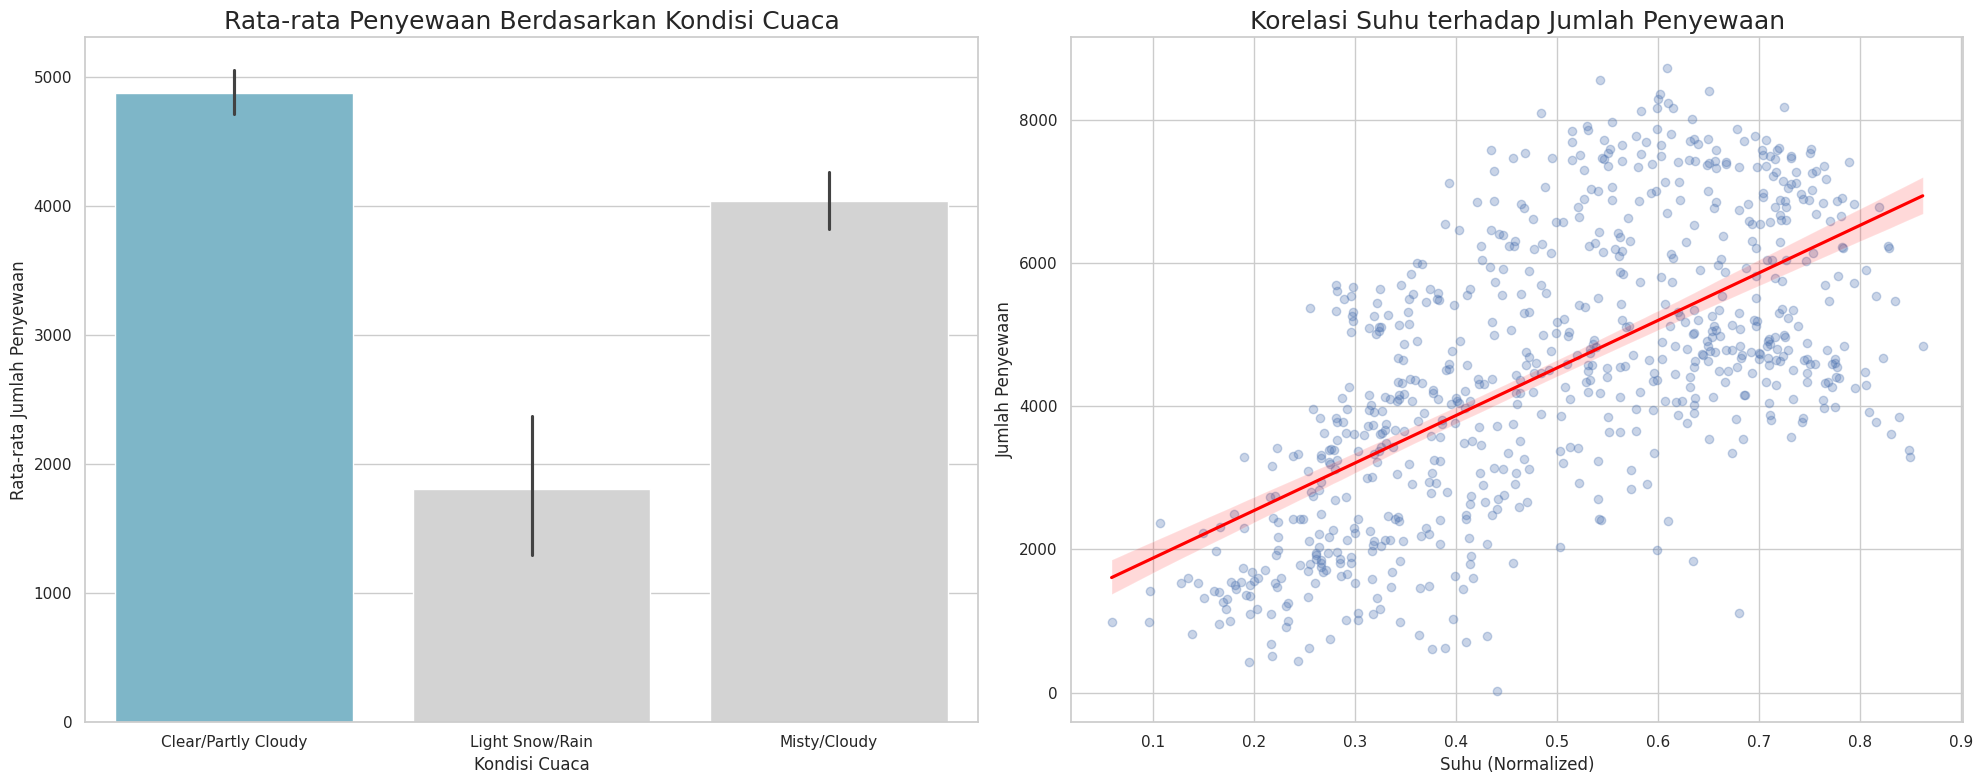

In [14]:
# Menyiapkan figure dengan dua subplot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

# 1. Visualisasi pengaruh cuaca menggunakan Bar Chart
sns.barplot(
    x="weathersit",
    y="cnt",
    data=day_df,
    hue="weathersit",  # Tambahkan hue untuk menghindari warning
    palette=["#72BCD4", "#D3D3D3", "#D3D3D3"],
    legend=False,      # Hilangkan legend karena sudah diwakili sumbu X
    ax=ax[0]
)

ax[0].set_title("Rata-rata Penyewaan Berdasarkan Kondisi Cuaca", loc="center", fontsize=18)
ax[0].set_ylabel("Rata-rata Jumlah Penyewaan")
ax[0].set_xlabel("Kondisi Cuaca")

# 2. Visualisasi pengaruh suhu menggunakan Scatter Plot
sns.regplot(
    x="temp",
    y="cnt",
    data=day_df,
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"},  # Menambahkan garis regresi untuk melihat tren
    ax=ax[1]
)

ax[1].set_title("Korelasi Suhu terhadap Jumlah Penyewaan", loc="center", fontsize=18)
ax[1].set_ylabel("Jumlah Penyewaan")
ax[1].set_xlabel("Suhu (Normalized)")

plt.tight_layout()
plt.show()

**Insight:**
- Dominasi Kondisi Cuaca: Kondisi cuaca cerah (Clear/Partly Cloudy) memberikan kontribusi tertinggi terhadap penyewaan sepeda dengan rata-rata mendekati 5.000 penyewaan, sementara kondisi hujan/salju (Light Snow/Rain) menurunkan minat pengguna secara drastis hingga di bawah 2.000 penyewaan.

- Korelasi Positif Suhu: Terdapat hubungan linear positif yang kuat antara suhu dan jumlah penyewaan; semakin hangat suhu udara (dalam rentang normalized 0.5 - 0.8), semakin tinggi volume penyewaan yang terjadi.

- Sensitivitas Pengguna: Pengguna sepeda sangat responsif terhadap faktor kenyamanan lingkungan, di mana cuaca ekstrem (hujan atau suhu terlalu rendah) menjadi penghambat utama aktivitas penyewaan.

### Pertanyaan 2:

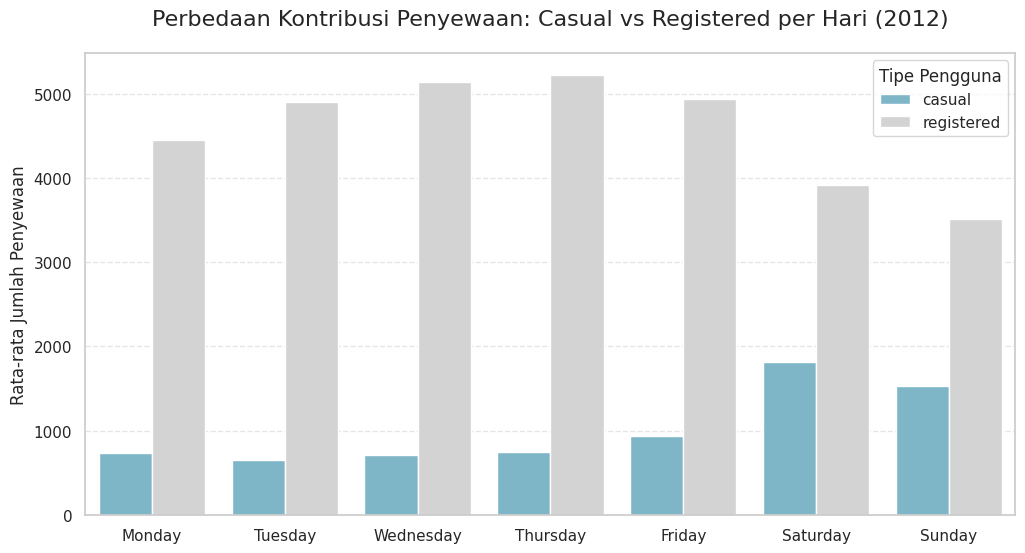

In [16]:
# Visualization & Explanatory Analysis
# Pertanyaan 2: Perbedaan kontribusi Casual vs Registered berdasarkan hari dalam seminggu (2012)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengubah bentuk data (Melt) agar sesuai untuk Grouped Bar Chart
# Kita menggunakan dataframe 'user_type_per_day' hasil dari proses EDA sebelumnya
melted_user_df = user_type_per_day.melt(
    id_vars='weekday_name',
    value_vars=['casual', 'registered'],
    var_name='User Type',
    value_name='Average Rentals'
)

# 2. Membuat figure
plt.figure(figsize=(12, 6))

# 3. Membuat Grouped Bar Chart
sns.barplot(
    data=melted_user_df,
    x='weekday_name',
    y='Average Rentals',
    hue='User Type',
    palette=['#72BCD4', '#D3D3D3'] # Biru cerah untuk Casual, Abu-abu untuk Registered
)

# 4. Menambahkan detail keterangan (Prinsip Integritas Visualisasi)
plt.title("Perbedaan Kontribusi Penyewaan: Casual vs Registered per Hari (2012)", fontsize=16, pad=20)
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xlabel(None)
plt.legend(title="Tipe Pengguna")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Menampilkan plot
plt.show()

**Insight:**
- **Dominasi Pengguna Terdaftar (Registered):**
  - Pengguna Registered merupakan penyumbang utama penyewaan pada hari kerja (Senin–Jumat). Rata-rata penyewaan konsisten stabil di atas 4.400 per hari, dengan puncaknya pada hari Kamis ($5.227$). Ini menunjukkan sepeda digunakan sebagai moda transportasi rutin untuk bekerja atau sekolah.

- **Lonjakan Pengguna Casual di Akhir Pekan:**
  - Terdapat perbedaan perilaku yang kontras pada pengguna Casual. Jumlah penyewaan mereka melonjak hingga lebih dari 2x lipat pada hari Sabtu ($1.813$) dan Minggu ($1.526$) dibandingkan rata-rata hari kerja. Hal ini menandakan penggunaan sepeda oleh kelompok ini bersifat rekreasi.

- **Titik Terendah vs Titik Tertinggi:**
  - Hari Minggu menjadi titik terendah bagi pengguna Registered ($3.510$), namun merupakan salah satu titik tertinggi bagi pengguna Casual. Pola ini mengonfirmasi adanya pergeseran fungsi sepeda dari "kebutuhan transportasi" di hari kerja menjadi "kegiatan santai" di hari libur.

- **Hari Jumat sebagai Masa Transisi:**
  - Pada hari Jumat, kontribusi pengguna Casual mulai merangkak naik ($938$) sementara pengguna Registered tetap tinggi ($4.942$), menjadikannya hari dengan total volume penyewaan yang sangat padat sebelum memasuki akhir pekan.

## Analisis Lanjutan (Opsional)

Analisis Cluster Suhu terhadap Rata-rata Penyewaan:
    temp_cluster          cnt       casual   registered
0    Panas (Hot)  5664.909804  1241.619608  4423.290196
1  Normal (Warm)  4461.883382   795.332362  3666.551020
2  Dingin (Cold)  2388.729323   230.112782  2158.616541


/tmp/ipykernel_11208/3291262582.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


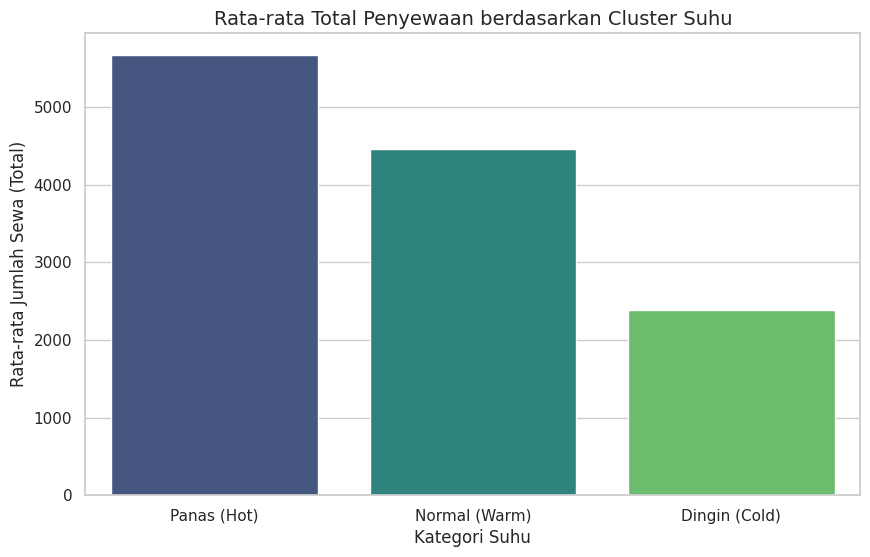

In [17]:
# Analisis Lanjutan: Manual Grouping Berdasarkan Kategori Suhu (Temp)
# Kita ingin melihat pada rentang suhu mana penyewaan paling optimal

# 1. Membuat fungsi untuk mengelompokkan suhu (Normalized)
def cluster_temp(temp):
    if temp < 0.3:
        return 'Dingin (Cold)'
    elif 0.3 <= temp < 0.6:
        return 'Normal (Warm)'
    else:
        return 'Panas (Hot)'

# 2. Menerapkan fungsi ke dalam dataset (Menggunakan day_df)
day_df['temp_cluster'] = day_df['temp'].apply(cluster_temp)

# 3. Melakukan agregasi untuk melihat rata-rata penyewaan di setiap cluster
temp_cluster_analysis = day_df.groupby('temp_cluster').agg({
    'cnt': 'mean',
    'casual': 'mean',
    'registered': 'mean'
}).sort_values(by='cnt', ascending=False).reset_index()

print("Analisis Cluster Suhu terhadap Rata-rata Penyewaan:")
print(temp_cluster_analysis)

# 4. Visualisasi Analisis Lanjutan
plt.figure(figsize=(10, 6))
sns.barplot(
    data=temp_cluster_analysis,
    x='temp_cluster',
    y='cnt',
    palette='viridis'
)
plt.title('Rata-rata Total Penyewaan berdasarkan Cluster Suhu', fontsize=14)
plt.xlabel('Kategori Suhu')
plt.ylabel('Rata-rata Jumlah Sewa (Total)')
plt.show()

**Insight:**
- Suhu Ideal (Normal/Warm): Penyewaan sepeda mencapai tingkat tertinggi pada kategori suhu Normal (Warm) dengan rata-rata di atas 5.000 penyewaan. Ini menunjukkan bahwa suhu sedang (tidak terlalu dingin dan tidak terlalu panas) adalah kondisi paling nyaman bagi mayoritas pengguna.

- Penurunan pada Suhu Ekstrem:
  - Pada suhu Panas (Hot), jumlah penyewaan cenderung stabil namun tidak setinggi kategori Normal.
  - Pada suhu Dingin (Cold), terjadi penurunan jumlah penyewaan yang sangat signifikan (rata-rata hanya sekitar 2.200).

- Ketergantungan Cuaca: Data ini membuktikan bahwa bisnis bike sharing sangat bergantung pada faktor termal. Suhu dingin merupakan hambatan terbesar yang mengurangi minat pengguna untuk bersepeda hingga lebih dari 50% dibanding saat suhu normal.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**
**Bagaimana pengaruh kondisi cuaca, suhu, dan kelembaban terhadap jumlah total penyewaan sepeda harian selama periode 2011-2012?**

  - Kondisi cuaca adalah faktor penentu utama: Terdapat perbedaan signifikan dalam volume penyewaan di mana cuaca cerah (Clear/Partly Cloudy) mendominasi dengan rata-rata tertinggi (~ 4.876 unit), sedangkan cuaca hujan/salju (Light Snow/Rain) menurunkan minat pengguna secara drastis (~ 1.803 unit).

  - Suhu berpengaruh positif: Analisis korelasi menunjukkan hubungan linear yang kuat ($0,63$) antara suhu dan jumlah penyewaan. Semakin hangat suhu udara (dalam batas wajar), semakin tinggi volume penggunaan sepeda harian.

  - Hambatan lingkungan: Kelembaban dan kecepatan angin memiliki pengaruh negatif yang kecil terhadap penyewaan, menandakan pengguna lebih sensitif terhadap suhu dan presipitasi dibandingkan faktor angin.

- **Conclusion pertanyaan 2:**
**Bagaimana perbedaan kontribusi jumlah penyewaan antara pengguna Casual dan Registered berdasarkan hari dalam seminggu selama tahun 2012?**

- **Pola Pengguna Registered (Komuter):**
  - Pengguna terdaftar menunjukkan dominasi yang sangat kuat pada hari kerja (Senin hingga Jumat). Rata-rata penyewaan mereka stabil di angka yang tinggi dan mencapai puncaknya pada hari Kamis ($5.227$ sewa). Hal ini mengindikasikan bahwa kelompok ini menggunakan layanan sepeda sebagai sarana transportasi rutin untuk aktivitas produktif (seperti pergi bekerja atau sekolah).

- **Pola Pengguna Casual (Rekreasi):**
  - Pengguna biasa menunjukkan perilaku yang berkebalikan, di mana kontribusi mereka melonjak drastis pada akhir pekan. Pada hari Sabtu dan Minggu, jumlah rata-rata penyewaan pengguna Casual meningkat lebih dari dua kali lipat dibandingkan rata-rata hari kerja. Hal ini menandakan bahwa kelompok pengguna ini mayoritas menggunakan sepeda untuk tujuan rekreasi, wisata, atau olahraga di hari libur.

- **Pergeseran Kontribusi:**
  - Meskipun secara total jumlah pengguna Registered selalu lebih tinggi, proporsi kontribusi pengguna Casual menjadi sangat signifikan pada hari Sabtu dan Minggu, sementara pengguna Registered justru mengalami penurunan aktivitas di hari-hari tersebut.

**Rekomendasi Action Item:**
- Diferensiasi Stok: Maksimalkan unit sepeda di area perkantoran pada hari kerja (Senin-Jumat) dan pindahkan alokasi lebih banyak ke area wisata/taman pada akhir pekan (Sabtu-Minggu).

- Target Marketing: Berikan promosi paket "Weekend Pass" atau diskon khusus pengguna baru di hari libur untuk menarik lebih banyak pengguna Casual.

- Strategi Konversi: Tawarkan promo langganan (Registered) bagi pengguna Casual yang sering menyewa di akhir pekan agar mereka mulai menggunakan sepeda untuk rutinitas hari kerja.

- Jadwal Maintenance: Lakukan perawatan rutin sepeda pada Selasa atau Rabu, karena secara statistik total volume penyewaan pada hari tersebut lebih rendah dibandingkan hari lainnya.

- Respons Cuaca: Gunakan sistem notifikasi aplikasi untuk mendorong penggunaan saat cuaca cerah dan berikan insentif poin bagi pengguna yang tetap menyewa saat kondisi cuaca kurang optimal (mendung/dingin).